<a href="https://colab.research.google.com/github/svetazo060510/goit-numpr-hw-09/blob/main/HW9_StremedlovskaS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання Тема 8

In [26]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [28]:
# ==========================================================
# 1. НАЛАШТУВАННЯ СЕРЕДОВИЩА (FrozenLake-v1)
# ==========================================================
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True, render_mode="rgb_array")
n_states = env.observation_space.n
n_actions = env.action_space.n
desc = env.unwrapped.desc
rows, cols = desc.shape

print(f"✅ Середовище FrozenLake {rows}x{cols} створено.")
print(f"Станів: {n_states}, Дій: {n_actions}")

✅ Середовище FrozenLake 4x4 створено.
Станів: 16, Дій: 4


In [29]:
# ==========================================================
# 2. ФУНКЦІЇ ВІЗУАЛІЗАЦІЇ
# ==========================================================

def plot_value_function(V, env, title="State Value Function V(s)"):
    value_grid = np.array(V).reshape(rows, cols)
    annotations = []
    for i in range(rows):
        row_ann = []
        for j in range(cols):
            cell = desc[i, j].decode()
            if cell == "H": row_ann.append("H")
            elif cell == "G": row_ann.append("G")
            else: row_ann.append(f"{value_grid[i, j]:.3f}")
        annotations.append(row_ann)

    plt.figure(figsize=(7, 5))
    mask = np.zeros_like(value_grid, dtype=bool)
    for i in range(rows):
        for j in range(cols):
            if desc[i, j].decode() in ["H", "G"]: mask[i, j] = True

    sns.heatmap(value_grid, annot=annotations, fmt="", cmap="YlGnBu",
                mask=mask, cbar=True, square=True, linewidths=1, linecolor="black")
    plt.title(title)
    plt.xticks([]); plt.yticks([])
    plt.show()

def plot_policy(policy, env, title="Policy"):
    policy_grid = np.array(policy).reshape(rows, cols)
    action_symbols = {0: "←", 1: "↓", 2: "→", 3: "↑"}
    annotations = []
    dummy_values = np.zeros((rows, cols))

    for i in range(rows):
        row_ann = []
        for j in range(cols):
            cell = desc[i, j].decode()
            if cell == "H": row_ann.append("H")
            elif cell == "G": row_ann.append("G")
            elif cell == "S": row_ann.append("S")
            else: row_ann.append(action_symbols[policy_grid[i, j]])
        annotations.append(row_ann)

    plt.figure(figsize=(7, 5))
    sns.heatmap(dummy_values, annot=annotations, fmt="", cmap="Pastel1",
                cbar=False, square=True, linewidths=1, linecolor="black")
    plt.title(title)
    plt.xticks([]); plt.yticks([])
    plt.show()

def animate_policy_history(policy_history, env, interval=500):
    action_symbols = {0: "←", 1: "↓", 2: "→", 3: "↑"}
    action_colors = {0: "#f8d7da", 1: "#d1ecf1", 2: "#d4edda", 3: "#fff3cd"}

    fig, ax = plt.subplots(figsize=(6, 6))

    def update(frame_idx):
        ax.clear()
        policy = np.array(policy_history[frame_idx]).reshape(rows, cols)
        for i in range(rows):
            for j in range(cols):
                cell = desc[i, j].decode()
                state = i * cols + j
                if cell == "H": facecolor, label = "lightblue", "H"
                elif cell == "G": facecolor, label = "lightgreen", "G"
                else:
                    action = policy[i, j]
                    facecolor = action_colors[action]
                    label = "S" if cell == "S" else action_symbols[action]

                rect = Rectangle((j, rows - i - 1), 1, 1, facecolor=facecolor, edgecolor="black", linewidth=1.5)
                ax.add_patch(rect)
                ax.text(j + 0.5, rows - i - 0.42, label, ha="center", va="center", fontsize=14, weight="bold")
                ax.text(j + 0.08, rows - i - 0.15, f"s={state}", ha="left", va="top", fontsize=8)

        ax.set_xlim(0, cols); ax.set_ylim(0, rows)
        ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"POLICY ITERATION: STEP {frame_idx + 1}")

    anim = FuncAnimation(fig, update, frames=len(policy_history), interval=interval, repeat=False)
    plt.close(fig)
    return HTML(anim.to_jshtml())

In [30]:
# ==========================================================
# 3. МАТЕМАТИЧНЕ ВИКОНАННЯ: POLICY ITERATION
# ==========================================================

def compute_value_function(policy, env, gamma=0.99, theta=1e-8, V_start=None):
    # Використання Warm Start для прискорення обчислень
    V = np.zeros(n_states) if V_start is None else V_start.copy()

    while True:
        delta = 0
        for s in range(n_states):
            v = 0
            action = policy[s]
            # Рівняння Беллмана
            for prob, next_state, reward, done in env.unwrapped.P[s][action]:
                v += prob * (reward + gamma * V[next_state])

            delta = max(delta, np.abs(v - V[s]))
            V[s] = v
        if delta < theta:
            break
    return V

def policy_iteration(env, gamma=0.99):
    policy = np.zeros(n_states, dtype=int)
    policy_history = []
    V = np.zeros(n_states)

    while True:
        policy_history.append(policy.copy())

        # Етап Policy Evaluation (Оцінка)
        V = compute_value_function(policy, env, gamma, V_start=V)

        # Етап Policy Improvement (Покращення)
        policy_stable = True
        for s in range(n_states):
            old_action = policy[s]
            action_values = np.zeros(n_actions)
            for a in range(n_actions):
                for prob, next_state, reward, done in env.unwrapped.P[s][a]:
                    action_values[a] += prob * (reward + gamma * V[next_state])

            new_action = np.argmax(action_values)
            policy[s] = new_action
            if old_action != new_action:
                policy_stable = False

        if policy_stable:
            policy_history.append(policy.copy())
            break
    return policy, V, policy_history


ЗАПУСК ЕКСПЕРИМЕНТІВ (Вплив Gamma)...
Gamma 0.1: знайдено за 8 кроків.


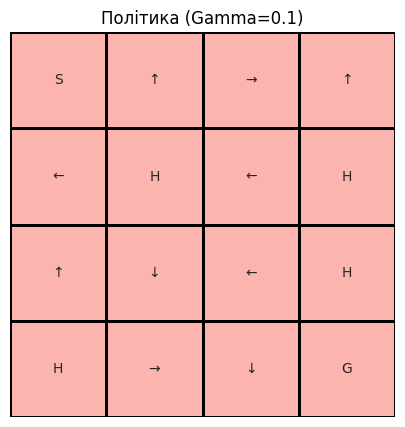

Gamma 0.5: знайдено за 6 кроків.


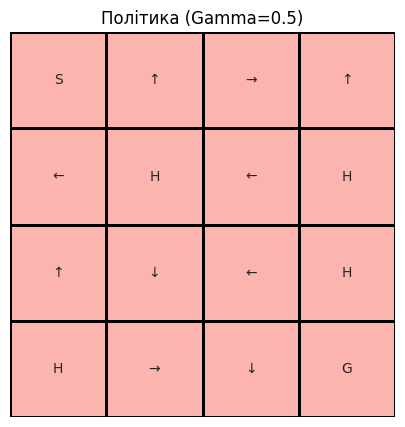

Gamma 0.99: знайдено за 7 кроків.


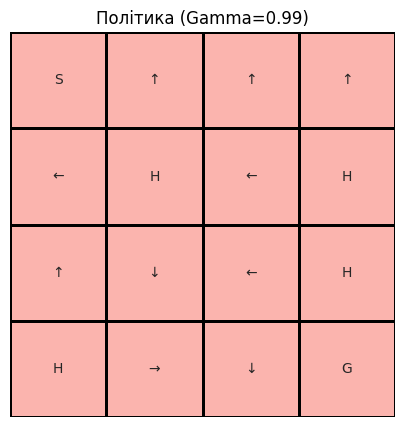


🏆 ФІНАЛЬНИЙ АНАЛІЗ (Gamma = 0.99)


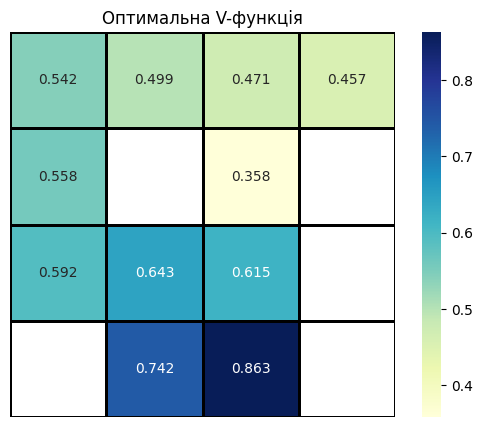


🏃 Агент пройшов озеро за 21 ходів.

🎬 Генеруємо анімацію...


In [34]:
# ==========================================================
# 4. ЕКСПЕРИМЕНТИ ТА ТЕСТУВАННЯ
# ==========================================================

# А. Тестування різних значень Gamma
gamma_values = [0.1, 0.5, 0.99]
results = {}

print("\nЗАПУСК ЕКСПЕРИМЕНТІВ (Вплив Gamma)...")
for g in gamma_values:
    p, v, p_hist = policy_iteration(env, gamma=g)
    results[g] = (p, v, p_hist)
    print(f"Gamma {g}: знайдено за {len(p_hist)-1} кроків.")
    plot_policy(p, env, title=f"Політика (Gamma={g})")

# Б. Фінальний аналіз (Gamma=0.99)
best_p, best_v, best_hist = results[0.99]
print("\n🏆 ФІНАЛЬНИЙ АНАЛІЗ (Gamma = 0.99)")
plot_value_function(best_v, env, "Оптимальна V-функція")

# В. Тест на кількість ходів
state, _ = env.reset()
steps = 0
done = False
while not done:
    state, reward, term, trunc, _ = env.step(best_p[state])
    steps += 1
    done = term or trunc

print(f"\n🏃 Агент пройшов озеро за {steps} ходів.")

# Г. Анімація еволюції стратегії
print("\n🎬 Генеруємо анімацію...")
animate_policy_history(best_hist, env, interval=700)